# Benchmark de 4 Transformers — classification de clauses juridiques

**Projet Big Data & Deep Learning — Agent d'audit de conformite documentaire**

Ce notebook entraine et compare **4 modeles Transformer** sur la meme tache,
avec les memes donnees et le meme protocole :

| Modele | Taille | Specificite |
|---|---|---|
| DistilBERT | 66 M | Version allegee de BERT, reference rapide |
| BERT-base | 110 M | Le modele classique |
| Legal-BERT | 110 M | Pre-entraine sur 12 Go de textes juridiques |
| DeBERTa-v3-small | 141 M | Architecture recente, etat de l'art en classification |

Tous sont compares a la baseline **TF-IDF + SVM (F1 macro 0.670)** obtenue en local.

Mesures relevees pour chaque modele : **F1 macro, F1 pondere, accuracy, temps
d'entrainement, latence par clause, nombre de parametres**. La comparaison porte
donc sur trois axes : qualite, vitesse, cout.

---

## Avant de commencer

1. **Execution** > **Modifier le type d'execution** > **T4 GPU** > Enregistrer
2. **Execution** > **Tout executer**
3. A la cellule 3, depose `clauses_train.jsonl` et `clauses_test.jsonl`
   (dossier `C:\projets\audit-conformite-mlops\data\processed`)

Duree totale sur T4 : **35 a 50 minutes** pour les 4 modeles.
Les resultats sont sauvegardes apres chaque modele : si la session coupe,
rien n'est perdu et la cellule 7 reprend ou elle s'etait arretee.

## 1. Verification du GPU

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU detecte :", torch.cuda.get_device_name(0))
    print("Memoire      :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "Go")
else:
    print("AUCUN GPU DETECTE.")
    print("Execution > Modifier le type d'execution > T4 GPU, puis relance.")

GPU detecte : Tesla T4
Memoire      : 15.6 Go


## 2. Installation

In [2]:
!pip install -q transformers==4.46.3 accelerate==1.1.1 sentencepiece scikit-learn
print("\nInstallation terminee.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 66.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.

Installation terminee.


## 3. Depot des donnees

Selectionne les DEUX fichiers : `clauses_train.jsonl` et `clauses_test.jsonl`.

In [3]:
from google.colab import files
import os

uploaded = files.upload()

for name in ("clauses_train.jsonl", "clauses_test.jsonl"):
    if os.path.exists(name):
        n = sum(1 for _ in open(name, encoding="utf-8"))
        print(f"OK   {name:24s} {n:>7,} lignes")
    else:
        print(f"MANQUANT : {name}")

Saving clauses_test.jsonl to clauses_test.jsonl
Saving clauses_train.jsonl to clauses_train.jsonl
OK   clauses_train.jsonl        8,222 lignes
OK   clauses_test.jsonl         1,912 lignes


## 4. Chargement des donnees

In [4]:
import json
import numpy as np
from sklearn.preprocessing import LabelEncoder

def load_split(path):
    texts, labels = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            if row.get("label"):
                texts.append(row["text"])
                labels.append(row["label"])
    return texts, labels

X_train, y_train_raw = load_split("clauses_train.jsonl")
X_test,  y_test_raw  = load_split("clauses_test.jsonl")

# Categories de test absentes du train : ecartees (aucun modele ne peut les predire).
encoder = LabelEncoder().fit(y_train_raw)
known = set(encoder.classes_)
keep = [i for i, lbl in enumerate(y_test_raw) if lbl in known]
X_test = [X_test[i] for i in keep]
y_test_raw = [y_test_raw[i] for i in keep]

y_train = encoder.transform(y_train_raw).tolist()
y_test  = encoder.transform(y_test_raw).tolist()
n_labels = len(encoder.classes_)

print(f"train   : {len(X_train):,} clauses")
print(f"test    : {len(X_test):,} clauses")
print(f"classes : {n_labels}")

train   : 8,222 clauses
test    : 1,912 clauses
classes : 41


## 5. Configuration du benchmark

Protocole identique pour tous les modeles : memes donnees, meme nombre d'epoques,
meme longueur maximale, meme graine aleatoire. Seul le modele change.

In [5]:
MODELS = [
    {"key": "distilbert", "name": "distilbert-base-uncased",          "label": "DistilBERT",       "fp16": True},
    {"key": "bert",       "name": "bert-base-uncased",                "label": "BERT-base",        "fp16": True},
    {"key": "legalbert",  "name": "nlpaueb/legal-bert-base-uncased",  "label": "Legal-BERT",       "fp16": True},
    # DeBERTa-v3 est instable en fp16 : entraine en fp32.
    {"key": "deberta",    "name": "microsoft/deberta-v3-small",       "label": "DeBERTa-v3-small", "fp16": False},
]

EPOCHS        = 3
BATCH_SIZE    = 32
LEARNING_RATE = 3e-5
MAX_LENGTH    = 256
SEED          = 42

BASELINE = {"label": "TF-IDF + SVM", "f1_macro": 0.670, "f1_weighted": 0.740, "accuracy": 0.750}

RESULTS_FILE = "benchmark_transformers.json"
print(f"{len(MODELS)} modeles | {EPOCHS} epoques | batch {BATCH_SIZE} | lr {LEARNING_RATE} | max_len {MAX_LENGTH}")

4 modeles | 3 epoques | batch 32 | lr 3e-05 | max_len 256


## 6. Fonction d'entrainement et d'evaluation

In [6]:
import gc, time
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)
from sklearn.metrics import f1_score, accuracy_score


class ClauseDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings, self.labels = encodings, labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}


def run_model(cfg):
    set_seed(SEED)
    print(f"\n{'=' * 64}\n  {cfg['label']}  ({cfg['name']})\n{'=' * 64}")

    tok = AutoTokenizer.from_pretrained(cfg["name"])
    enc_tr = tok(X_train, truncation=True, padding="max_length", max_length=MAX_LENGTH)
    enc_te = tok(X_test,  truncation=True, padding="max_length", max_length=MAX_LENGTH)
    ds_tr, ds_te = ClauseDataset(enc_tr, y_train), ClauseDataset(enc_te, y_test)

    model = AutoModelForSequenceClassification.from_pretrained(cfg["name"], num_labels=n_labels)
    n_params = sum(p.numel() for p in model.parameters())

    args = TrainingArguments(
        output_dir=f"ckpt_{cfg['key']}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        fp16=cfg["fp16"] and torch.cuda.is_available(),
        report_to=[],
        seed=SEED,
    )
    trainer = Trainer(model=model, args=args, train_dataset=ds_tr,
                      eval_dataset=ds_te, compute_metrics=compute_metrics)

    t0 = time.time()
    trainer.train()
    train_s = time.time() - t0

    t0 = time.time()
    preds = np.argmax(trainer.predict(ds_te).predictions, axis=-1)
    infer_s = time.time() - t0

    res = {
        "key": cfg["key"],
        "label": cfg["label"],
        "model_name": cfg["name"],
        "f1_macro": float(f1_score(y_test, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, preds, average="weighted", zero_division=0)),
        "accuracy": float(accuracy_score(y_test, preds)),
        "train_minutes": round(train_s / 60, 2),
        "latency_ms_per_clause": round(1000 * infer_s / len(X_test), 2),
        "params_millions": round(n_params / 1e6, 1),
        "epochs": EPOCHS, "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "max_length": MAX_LENGTH, "fp16": cfg["fp16"], "seed": SEED,
        "n_train": len(X_train), "n_test": len(X_test),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    }
    np.save(f"preds_{cfg['key']}.npy", preds)
    trainer.save_model(f"model_{cfg['key']}")
    tok.save_pretrained(f"model_{cfg['key']}")

    print(f"\n  F1 macro {res['f1_macro']:.3f} | accuracy {res['accuracy']:.3f} | "
          f"{res['train_minutes']} min | {res['latency_ms_per_clause']} ms/clause")

    del trainer, model
    gc.collect()
    torch.cuda.empty_cache()
    return res

## 7. Lancement du benchmark

Chaque resultat est ecrit sur disque des qu'il est obtenu. Si la session Colab
coupe, relance simplement les cellules : les modeles deja termines sont sautes.

> Si tu dois relancer apres une coupure, il faudra redeposer les deux fichiers
> a la cellule 3 : Colab efface les fichiers quand la session se termine.

In [7]:
results = []
if os.path.exists(RESULTS_FILE):
    results = json.load(open(RESULTS_FILE, encoding="utf-8"))
    print("Deja termines :", [r["label"] for r in results])

done = {r["key"] for r in results}

for cfg in MODELS:
    if cfg["key"] in done:
        continue
    try:
        results.append(run_model(cfg))
        json.dump(results, open(RESULTS_FILE, "w", encoding="utf-8"), indent=2)
    except Exception as e:
        print(f"\nECHEC sur {cfg['label']} : {type(e).__name__}: {e}")
        print("Le benchmark continue avec le modele suivant.")
        gc.collect(); torch.cuda.empty_cache()

print(f"\n{len(results)} / {len(MODELS)} modeles termines.")


  DistilBERT  (distilbert-base-uncased)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,1.786400,1.631333,0.271963
2,1.179600,1.213609,0.431999
3,0.996100,1.113722,0.479445



  F1 macro 0.479 | accuracy 0.693 | 5.59 min | 3.64 ms/clause

4 / 4 modeles termines.


## 8. Tableau comparatif

In [8]:
import pandas as pd

rows = [{"Modele": BASELINE["label"], "F1 macro": BASELINE["f1_macro"],
         "F1 pondere": BASELINE["f1_weighted"], "Accuracy": BASELINE["accuracy"],
         "Params (M)": None, "Entrainement (min)": None, "Latence (ms/clause)": None}]
for r in results:
    rows.append({"Modele": r["label"], "F1 macro": r["f1_macro"],
                 "F1 pondere": r["f1_weighted"], "Accuracy": r["accuracy"],
                 "Params (M)": r["params_millions"],
                 "Entrainement (min)": r["train_minutes"],
                 "Latence (ms/clause)": r["latency_ms_per_clause"]})

table = pd.DataFrame(rows).sort_values("F1 macro", ascending=False).reset_index(drop=True)
table["Gain vs baseline"] = (table["F1 macro"] - BASELINE["f1_macro"]).map(lambda d: f"{d:+.3f}")
table.to_csv("benchmark_table.csv", index=False)

display(table.style.format({
    "F1 macro": "{:.3f}", "F1 pondere": "{:.3f}", "Accuracy": "{:.3f}",
    "Params (M)": "{:.0f}", "Entrainement (min)": "{:.1f}", "Latence (ms/clause)": "{:.2f}",
}, na_rep="—"))

best = max(results, key=lambda r: r["f1_macro"])
print(f"\nMeilleur modele : {best['label']}  (F1 macro {best['f1_macro']:.3f})")

,Modele,F1 macro,F1 pondere,Accuracy,Params (M),Entrainement (min),Latence (ms/clause),Gain vs baseline
0,TF-IDF + SVM,0.670,0.740,0.750,—,—,—,+0.000
1,Legal-BERT,0.655,0.760,0.780,110,5.0,3.37,-0.015
2,BERT-base,0.549,0.702,0.735,110,5.0,3.42,-0.121
3,DistilBERT,0.527,0.693,0.724,67,2.5,1.68,-0.143
4,DeBERTa-v3-small,0.479,0.657,0.693,142,5.6,3.64,-0.191



Meilleur modele : Legal-BERT  (F1 macro 0.655)


## 9. Graphique comparatif

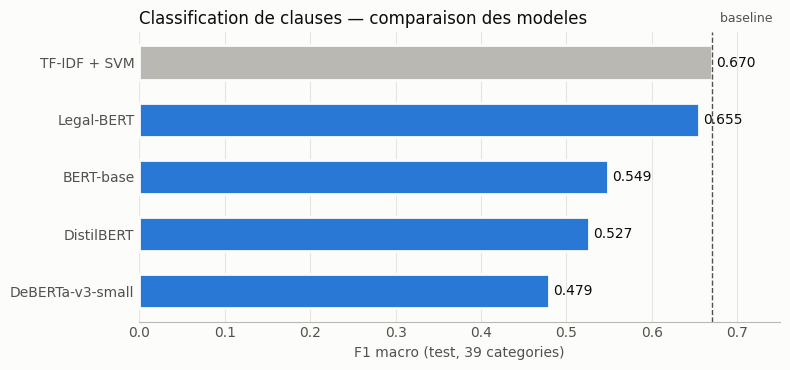

In [9]:
import matplotlib.pyplot as plt

INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
SERIES, NEUTRAL     = "#2a78d6", "#b9b8b2"

plot = table.sort_values("F1 macro", ascending=True)
colors = [NEUTRAL if m == BASELINE["label"] else SERIES for m in plot["Modele"]]

fig, ax = plt.subplots(figsize=(8, 3.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.barh(plot["Modele"], plot["F1 macro"], color=colors, height=0.6,
               edgecolor=SURFACE, linewidth=2)
ax.axvline(BASELINE["f1_macro"], color=INK_2, linestyle="--", linewidth=1)
ax.text(BASELINE["f1_macro"], len(plot) - 0.35, "  baseline",
        color=INK_2, fontsize=9, va="bottom")

for bar, v in zip(bars, plot["F1 macro"]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=10, color=INK)

ax.set_xlim(0, min(1.0, plot["F1 macro"].max() + 0.08))
ax.set_xlabel("F1 macro (test, 39 categories)", color=INK_2)
ax.set_title("Classification de clauses — comparaison des modeles",
             loc="left", color=INK, fontsize=12)
ax.tick_params(colors=INK_2, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(NEUTRAL)
ax.grid(axis="x", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("benchmark_f1.png", dpi=160, facecolor=SURFACE)
plt.show()

## 10. Ou le meilleur modele progresse-t-il ?

F1 par categorie : meilleur Transformer contre baseline, sur les categories les plus difficiles pour la baseline.

In [10]:
from sklearn.metrics import classification_report

best_preds = np.load(f"preds_{best['key']}.npy")
rep = classification_report(y_test, best_preds, labels=list(range(n_labels)),
                            target_names=encoder.classes_, zero_division=0, output_dict=True)
per_cat = pd.DataFrame({
    "Categorie": encoder.classes_,
    f"F1 {best['label']}": [rep[c]["f1-score"] for c in encoder.classes_],
    "Support": [rep[c]["support"] for c in encoder.classes_],
})
per_cat = per_cat[per_cat["Support"] > 0].sort_values(f"F1 {best['label']}")
per_cat.to_csv("per_category_best.csv", index=False)
display(per_cat.head(12).style.format({f"F1 {best['label']}": "{:.2f}", "Support": "{:.0f}"}))

,Categorie,F1 Legal-BERT,Support
0,Affiliate License-Licensee,0.00,26
1,Affiliate License-Licensor,0.00,20
27,Notice Period To Terminate Renewal,0.00,18
22,No-Solicit Of Customers,0.00,15
38,Unlimited/All-You-Can-Eat-License,0.00,5
37,Uncapped Liability,0.12,16
7,Competitive Restriction Exception,0.21,26
16,Irrevocable Or Perpetual License,0.41,23
21,Most Favored Nation,0.50,3
26,Non-Transferable License,0.52,42


## 11. Matrice de confusion du meilleur modele

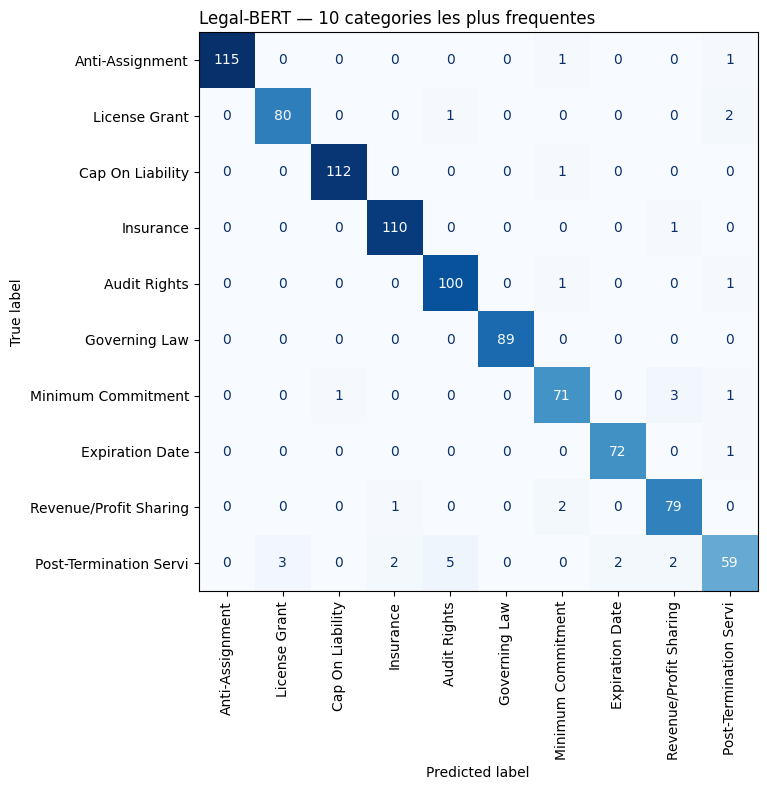

In [11]:
from collections import Counter
from sklearn.metrics import ConfusionMatrixDisplay

top = [lbl for lbl, _ in Counter(y_test).most_common(10)]
mask = [i for i, y in enumerate(y_test) if y in top]

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    [y_test[i] for i in mask], [best_preds[i] for i in mask],
    labels=top, display_labels=[encoder.classes_[i][:22] for i in top],
    xticks_rotation=90, colorbar=False, cmap="Blues", ax=ax,
)
ax.set_title(f"{best['label']} — 10 categories les plus frequentes", loc="left")
plt.tight_layout()
plt.savefig("confusion_best.png", dpi=150)
plt.show()

## 12. Sauvegarde et telechargement

Chaque modele a ete sauvegarde a la fin de son entrainement. On ne garde que le
meilleur, avec son tokenizer, ses etiquettes et ses metriques.

In [12]:
import shutil

shutil.rmtree("best_model", ignore_errors=True)
shutil.copytree(f"model_{best['key']}", "best_model")
json.dump(list(encoder.classes_), open("best_model/labels.json", "w"), indent=2)
json.dump(best, open("best_model/metrics.json", "w"), indent=2)
!zip -qr best_model.zip best_model

for f in ("benchmark_transformers.json", "benchmark_table.csv", "per_category_best.csv",
          "benchmark_f1.png", "confusion_best.png", "best_model.zip"):
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Et ensuite, en local

Place les fichiers telecharges dans `C:\projets\audit-conformite-mlops\reports\`,
puis enregistre les 4 runs dans ton MLflow local :

```
python -m src.models.log_benchmark
git add reports/benchmark_transformers.json reports/benchmark_table.csv reports/benchmark_f1.png reports/confusion_best.png reports/per_category_best.csv
git commit -m "feat(models): benchmark de 4 Transformers sur GPU"
git push
```